In [1]:
# ------------------------------
# SETUP: imports, helpers, models
# ------------------------------
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import clone

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------
# Load dataset
# ------------------------------
file_path = r"../Rice_Cammeo_Osmancik.xlsx"
df = pd.read_excel(file_path)

# use same 7 features as paper
features = [
    'Area','Perimeter','Major_Axis_Length',
    'Minor_Axis_Length','Eccentricity',
    'Convex_Area','Extent'
]

X = df[features]
y = df['Class']

# Encode target as numeric
y = LabelEncoder().fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------
# safe division to avoid divide by zero
# ------------------------------
def safe_div(a, b):
    return a / b if b != 0 else np.nan

# ------------------------------
# Compute all metrics from confusion matrix
# ------------------------------
def compute_metrics(cm):
    tn, fp, fn, tp = cm.ravel()
    return np.array([
        safe_div(tp + tn, tp + tn + fp + fn),   # Accuracy
        safe_div(tp, tp + fn),                 # Sensitivity / Recall
        safe_div(tn, tn + fp),                 # Specificity
        safe_div(tp, tp + fp),                 # Precision / PPV
        safe_div(2 * tp, 2 * tp + fp + fn),    # F1-score
        safe_div(tn, tn + fn),                 # NPV
        safe_div(fp, tn + fp),                 # FPR
        safe_div(fp, tp + fp),                 # FDR
        safe_div(fn, tp + fn)                  # FNR
    ])

# ------------------------------
# Train models using cross-validation
# ------------------------------
def train_models_cv(X, y, models, cv_splits=10):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    results = {}

    for name, model in models.items():
        fold_metrics = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            m = clone(model)  # ensure fresh model per fold
            m.fit(X_train, y_train)
            preds = m.predict(X_test)

            cm = confusion_matrix(y_test, preds)
            fold_metrics.append(compute_metrics(cm))

        results[name] = np.mean(fold_metrics, axis=0)

    measures = [
        "Accuracy","Sensitivity","Specificity","Precision",
        "F1-Score","NPV","FPR","FDR","FNR"
    ]

    return pd.DataFrame(results, index=measures) * 100

# ------------------------------
# Default models (replication)
# ------------------------------
def get_default_models():
    return {
        "LR": LogisticRegression(max_iter=1000),
        "MLP": MLPClassifier(max_iter=1000),
        "SVM": SVC(),
        "DT": DecisionTreeClassifier(),
        "RF": RandomForestClassifier(),
        "NB": GaussianNB(),
        "k-NN": KNeighborsClassifier(n_neighbors=1)
    }

# ------------------------------
# Hyperparameter tuned models
# ------------------------------
def get_tuned_models():
    return {
        "LR": LogisticRegression(max_iter=2000, C=1.0),
        "MLP": MLPClassifier(hidden_layer_sizes=(50,25), max_iter=2000),
        "SVM": SVC(kernel="rbf", C=10, gamma="scale"),
        "DT": DecisionTreeClassifier(max_depth=10, random_state=42),
        "RF": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
        "NB": GaussianNB(),
        "k-NN": KNeighborsClassifier(n_neighbors=5, weights="distance")
    }

# ------------------------------
# Print best models per metric
# ------------------------------
def get_best_models(results_df):
    best_models = results_df.idxmax(axis=1)
    best_values = results_df.max(axis=1)

    print("\nBest model per measure:\n")
    for measure in results_df.index:
        print(f"{measure:15s} -> {best_models[measure]} ({best_values[measure]:.2f}%)")

    print("\nWins per model:\n")
    print(best_models.value_counts())

In [2]:
# ------------------------------
# TRAIN BASELINE MODELS
# ------------------------------
default_models = get_default_models()
baseline_results = train_models_cv(X_scaled, y, default_models)

print("BASELINE (NON-TUNED) MODELS PERFORMANCE\n")
display(baseline_results.round(2))
get_best_models(baseline_results)

BASELINE (NON-TUNED) MODELS PERFORMANCE



,LR,MLP,SVM,DT,RF,NB,k-NN
Accuracy,92.94,92.76,92.89,87.87,92.34,91.71,88.74
Sensitivity,93.99,93.85,94.17,89.82,93.49,93.26,89.54
Specificity,91.53,91.29,91.17,85.28,90.80,89.63,87.67
Precision,93.71,93.54,93.46,89.11,93.16,92.36,90.71
F1-Score,93.84,93.68,93.81,89.44,93.31,92.78,90.10
NPV,91.96,91.77,92.16,86.28,91.30,90.95,86.26
FPR,8.47,8.71,8.83,14.72,9.20,10.37,12.33
FDR,6.29,6.46,6.54,10.89,6.84,7.64,9.29
FNR,6.01,6.15,5.83,10.18,6.51,6.74,10.46



Best model per measure:

Accuracy        -> LR (92.94%)
Sensitivity     -> SVM (94.17%)
Specificity     -> LR (91.53%)
Precision       -> LR (93.71%)
F1-Score        -> LR (93.84%)
NPV             -> SVM (92.16%)
FPR             -> DT (14.72%)
FDR             -> DT (10.89%)
FNR             -> k-NN (10.46%)

Wins per model:

LR      4
SVM     2
DT      2
k-NN    1
Name: count, dtype: int64


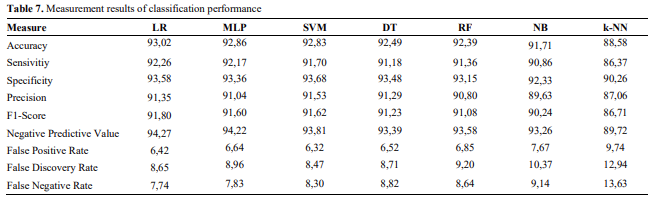

In [3]:
# ------------------------------
# TRAIN HYPERPARAMETER-TUNED MODELS
# ------------------------------
tuned_models = get_tuned_models()
tuned_results = train_models_cv(X_scaled, y, tuned_models)

print("HYPER-TUNED MODELS PERFORMANCE\n")
display(tuned_results.round(2))
get_best_models(tuned_results)

HYPER-TUNED MODELS PERFORMANCE



,LR,MLP,SVM,DT,RF,NB,k-NN
Accuracy,92.94,92.86,92.86,90.08,92.60,91.71,91.76
Sensitivity,93.99,93.99,94.17,91.83,93.94,93.26,92.89
Specificity,91.53,91.35,91.10,87.73,90.80,89.63,90.25
Precision,93.71,93.59,93.43,90.94,93.20,92.36,92.75
F1-Score,93.84,93.77,93.79,91.38,93.56,92.78,92.81
NPV,91.96,91.96,92.16,88.93,91.86,90.95,90.50
FPR,8.47,8.65,8.90,12.27,9.20,10.37,9.75
FDR,6.29,6.41,6.57,9.06,6.80,7.64,7.25
FNR,6.01,6.01,5.83,8.17,6.06,6.74,7.11



Best model per measure:

Accuracy        -> LR (92.94%)
Sensitivity     -> SVM (94.17%)
Specificity     -> LR (91.53%)
Precision       -> LR (93.71%)
F1-Score        -> LR (93.84%)
NPV             -> SVM (92.16%)
FPR             -> DT (12.27%)
FDR             -> DT (9.06%)
FNR             -> DT (8.17%)

Wins per model:

LR     4
DT     3
SVM    2
Name: count, dtype: int64


In [4]:
# ------------------------------
# SYNTHETIC DATA EXPERIMENT (10% extra)
# ------------------------------
from sklearn.utils import resample

# Fraction of synthetic data
synthetic_fraction = 0.10

# Compute number of synthetic samples
n_synthetic = int(len(X_scaled) * synthetic_fraction)

# Randomly sample indices from the original dataset
synthetic_idx = np.random.choice(len(X_scaled), size=n_synthetic, replace=True)

# Extract features and add small Gaussian noise
X_synthetic = X_scaled[synthetic_idx] + np.random.normal(0, 0.05, X_scaled[synthetic_idx].shape)
y_synthetic = y[synthetic_idx]  # keep original class

# Append to original dataset
X_augmented = np.vstack([X_scaled, X_synthetic])
y_augmented = np.hstack([y, y_synthetic])

print(f"Original dataset size: {len(X_scaled)}")
print(f"Augmented dataset size: {len(X_augmented)} (10% synthetic added)")

# Train hyper-tuned models on augmented data
synthetic_results = train_models_cv(X_augmented, y_augmented, tuned_models)

print("\nHYPER-TUNED MODELS WITH 10% SYNTHETIC DATA PERFORMANCE\n")
display(synthetic_results.round(2))
get_best_models(synthetic_results)

Original dataset size: 3810
Augmented dataset size: 4191 (10% synthetic added)

HYPER-TUNED MODELS WITH 10% SYNTHETIC DATA PERFORMANCE



,LR,MLP,SVM,DT,RF,NB,k-NN
Accuracy,92.87,92.70,92.77,90.38,92.87,91.72,91.98
Sensitivity,93.89,94.51,94.47,92.10,94.47,93.39,93.18
Specificity,91.49,90.26,90.49,88.08,90.71,89.48,90.38
Precision,93.71,92.93,93.06,91.24,93.21,92.30,92.90
F1-Score,93.79,93.69,93.74,91.65,93.82,92.83,93.02
NPV,91.80,92.50,92.46,89.29,92.46,91.00,90.86
FPR,8.51,9.74,9.51,11.92,9.29,10.52,9.62
FDR,6.29,7.07,6.94,8.76,6.79,7.70,7.10
FNR,6.11,5.49,5.53,7.90,5.53,6.61,6.82



Best model per measure:

Accuracy        -> LR (92.87%)
Sensitivity     -> MLP (94.51%)
Specificity     -> LR (91.49%)
Precision       -> LR (93.71%)
F1-Score        -> RF (93.82%)
NPV             -> MLP (92.50%)
FPR             -> DT (11.92%)
FDR             -> DT (8.76%)
FNR             -> DT (7.90%)

Wins per model:

LR     3
DT     3
MLP    2
RF     1
Name: count, dtype: int64


In [5]:
# ------------------------------
# SYNTHETIC DATA EXPERIMENT (MULTI-LEVEL)
# ------------------------------
synthetic_levels = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

# Store results for each level
experiment_results = {}

# Baseline: hyper-tuned on original data (0% synthetic)
baseline_hyper = train_models_cv(X_scaled, y, tuned_models)
experiment_results[0] = baseline_hyper

for level in synthetic_levels:
    n_synthetic = int(len(X_scaled) * level)

    synthetic_idx = np.random.choice(len(X_scaled), size=n_synthetic, replace=True)
    X_synthetic = X_scaled[synthetic_idx] + np.random.normal(0, 0.05, X_scaled[synthetic_idx].shape)
    y_synthetic = y[synthetic_idx]

    X_aug = np.vstack([X_scaled, X_synthetic])
    y_aug = np.hstack([y, y_synthetic])

    res = train_models_cv(X_aug, y_aug, tuned_models)
    experiment_results[level] = res

print("SYNTHETIC DATA EXPERIMENT COMPLETE")

SYNTHETIC DATA EXPERIMENT COMPLETE


In [6]:
# ------------------------------
# PREDICTIVE VALUE LOSS TABLE
# ------------------------------
baseline_accuracy = experiment_results[0].loc["Accuracy"]

loss_table = pd.DataFrame()

for level, df_res in experiment_results.items():
    if level == 0:  # skip baseline in table
        continue
    loss_table[f"{int(level*100)}% synthetic"] = baseline_accuracy - df_res.loc["Accuracy"]

print("\nPredictive value loss (Accuracy drop %) for each synthetic level:\n")
display(loss_table.round(2))

print("\nAverage predictive value loss per model:\n")
display(loss_table.mean(axis=1).round(2))

print("\nModel most resistant to predictive value loss:\n")
display(loss_table.mean(axis=1).sort_values())


Predictive value loss (Accuracy drop %) for each synthetic level:



,1% synthetic,5% synthetic,10% synthetic,15% synthetic,20% synthetic,30% synthetic,40% synthetic,50% synthetic,60% synthetic,70% synthetic,80% synthetic
LR,0.16,0.01,-0.16,0.15,0.31,0.09,-0.18,0.31,0.17,-0.07,0.43
MLP,0.48,0.22,0.13,0.15,0.49,0.24,-0.12,0.19,0.29,-0.11,0.20
SVM,0.11,-0.11,-0.24,0.12,0.14,-0.03,-0.13,0.05,0.13,-0.30,0.05
DT,0.06,-0.85,-1.38,-0.88,-0.63,-1.10,-1.78,-1.15,-1.33,-2.20,-1.49
RF,0.08,-0.15,-0.31,-0.42,-0.21,-0.44,-0.82,-0.40,-0.50,-0.81,-0.81
NB,0.02,-0.02,-0.20,-0.03,0.21,-0.08,-0.27,0.44,-0.06,-0.16,0.21
k-NN,0.10,-0.09,-0.41,-0.64,-0.83,-1.32,-1.62,-1.50,-1.98,-2.82,-2.57



Average predictive value loss per model:



LR      0.11
MLP     0.20
SVM    -0.02
DT     -1.16
RF     -0.43
NB      0.01
k-NN   -1.24
dtype: float64


Model most resistant to predictive value loss:



k-NN   -1.244220
DT     -1.157547
RF     -0.434741
SVM    -0.019289
NB      0.005669
LR      0.111975
MLP     0.195942
dtype: float64

In [7]:
# ------------------------------
# SYNTHETIC REPLACEMENT EXPERIMENT
# ------------------------------
replacement_levels = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

replacement_results = {}

# Baseline: hyper-tuned on original data
baseline_hyper = train_models_cv(X_scaled, y, tuned_models)
replacement_results[0] = baseline_hyper

for level in replacement_levels:
    n_replace = int(len(X_scaled) * level)

    # Randomly choose indices to replace
    replace_idx = np.random.choice(len(X_scaled), size=n_replace, replace=False)

    # Create synthetic data for these indices
    X_synthetic = X_scaled[replace_idx] + np.random.normal(0, 0.05, X_scaled[replace_idx].shape)
    y_synthetic = y[replace_idx]  # keep original class

    # Copy original data
    X_mod = X_scaled.copy()
    y_mod = y.copy()

    # Replace selected rows with synthetic
    X_mod[replace_idx] = X_synthetic
    y_mod[replace_idx] = y_synthetic

    # Train models on modified dataset
    res = train_models_cv(X_mod, y_mod, tuned_models)
    replacement_results[level] = res

print("SYNTHETIC REPLACEMENT EXPERIMENT COMPLETE")

SYNTHETIC REPLACEMENT EXPERIMENT COMPLETE


In [8]:
# ------------------------------
# LOSS TABLE FOR REPLACEMENT EXPERIMENT
# ------------------------------
baseline_accuracy = replacement_results[0].loc["Accuracy"]

loss_table_replace = pd.DataFrame()

for level, df_res in replacement_results.items():
    if level == 0:
        continue
    loss_table_replace[f"{int(level*100)}% synthetic replace"] = baseline_accuracy - df_res.loc["Accuracy"]

print("\nPredictive value loss (Accuracy drop %) for synthetic replacement levels:\n")
display(loss_table_replace.round(2))

print("\nAverage predictive value loss per model:\n")
display(loss_table_replace.mean(axis=1).round(2))

print("\nModel most resistant to predictive value loss:\n")
display(loss_table_replace.mean(axis=1).sort_values())


Predictive value loss (Accuracy drop %) for synthetic replacement levels:



,1% synthetic replace,5% synthetic replace,10% synthetic replace,15% synthetic replace,20% synthetic replace,30% synthetic replace,40% synthetic replace,50% synthetic replace,60% synthetic replace,70% synthetic replace,80% synthetic replace
LR,0.00,0.03,0.08,0.00,0.16,0.18,-0.03,0.05,0.16,0.18,0.24
MLP,0.00,0.03,-0.10,0.05,-0.16,0.05,0.03,-0.05,-0.13,0.21,0.16
SVM,0.08,0.03,-0.10,-0.03,0.00,0.03,-0.05,0.10,-0.03,-0.13,0.37
DT,0.08,-0.29,-0.16,-0.63,-0.63,-0.26,-0.24,-0.18,-0.45,-0.03,-0.31
RF,0.16,-0.03,0.18,0.21,0.13,-0.05,0.10,-0.05,-0.10,-0.08,0.08
NB,0.03,0.00,0.03,0.03,-0.05,0.05,0.00,-0.03,-0.03,0.13,-0.03
k-NN,0.00,0.00,-0.08,-0.03,0.21,0.00,0.18,0.00,0.26,0.34,0.13



Average predictive value loss per model:



LR      0.10
MLP     0.01
SVM     0.02
DT     -0.28
RF      0.05
NB      0.01
k-NN    0.09
dtype: float64


Model most resistant to predictive value loss:



DT     -0.281556
MLP     0.007158
NB      0.011930
SVM     0.023861
RF      0.050107
k-NN    0.093057
LR      0.095443
dtype: float64